In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import pickle

Load Dataset

In [2]:
df = pd.read_csv("sales_forecasting_dataset.csv")

In [3]:
df.head()

,Date,Product_ID,Store_ID,Units_Sold,Revenue,Promotion,Holiday
0,2022-01-01,P101,S1,129,3870,1,0
1,2022-01-01,P101,S2,119,4760,0,0
2,2022-01-01,P101,S3,126,5418,0,0
3,2022-01-01,P102,S1,137,5480,1,0
4,2022-01-01,P102,S2,114,5358,0,0


In [4]:
df.tail()

,Date,Product_ID,Store_ID,Units_Sold,Revenue,Promotion,Holiday
16435,2024-12-31,P104,S2,118,2832,0,0
16436,2024-12-31,P104,S3,125,4000,0,0
16437,2024-12-31,P105,S1,127,3556,0,0
16438,2024-12-31,P105,S2,123,5166,0,0
16439,2024-12-31,P105,S3,127,6223,0,0


In [5]:
df.shape

(16440, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16440 entries, 0 to 16439
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        16440 non-null  object
 1   Product_ID  16440 non-null  object
 2   Store_ID    16440 non-null  object
 3   Units_Sold  16440 non-null  int64 
 4   Revenue     16440 non-null  int64 
 5   Promotion   16440 non-null  int64 
 6   Holiday     16440 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 899.2+ KB


In [7]:
df.describe()

,Units_Sold,Revenue,Promotion,Holiday
count,16440.000000,16440.000000,16440.000000,16440.000000
mean,118.287287,4091.612409,0.300730,0.143248
std,18.791799,1217.175399,0.458589,0.350336
min,41.000000,960.000000,0.000000,0.000000
25%,105.000000,3131.750000,0.000000,0.000000
50%,118.000000,3993.000000,0.000000,0.000000
75%,131.000000,4953.000000,1.000000,0.000000
max,193.000000,8477.000000,1.000000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Date          0
Product_ID    0
Store_ID      0
Units_Sold    0
Revenue       0
Promotion     0
Holiday       0
dtype: int64

Data Preprocessing

In [10]:
#### Convert Date column

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
#### Sort data

In [13]:
df = df.sort_values('Date')

In [14]:
#### Handle missing values

In [15]:
df.fillna(method='ffill', inplace=True)

C:\Users\sim\AppData\Local\Temp\ipykernel_18140\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Feature Engineering

In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [17]:
df['Year']

0        2022
14       2022
13       2022
12       2022
11       2022
         ... 
16426    2024
16425    2024
16438    2024
16431    2024
16439    2024
Name: Year, Length: 16440, dtype: int32

In [18]:
df['Month']

0         1
14        1
13        1
12        1
11        1
         ..
16426    12
16425    12
16438    12
16431    12
16439    12
Name: Month, Length: 16440, dtype: int32

In [19]:
df['Day']

0         1
14        1
13        1
12        1
11        1
         ..
16426    31
16425    31
16438    31
16431    31
16439    31
Name: Day, Length: 16440, dtype: int32

In [20]:
df['DayOfWeek']

0        5
14       5
13       5
12       5
11       5
        ..
16426    1
16425    1
16438    1
16431    1
16439    1
Name: DayOfWeek, Length: 16440, dtype: int32

Exploratory Data Analysis

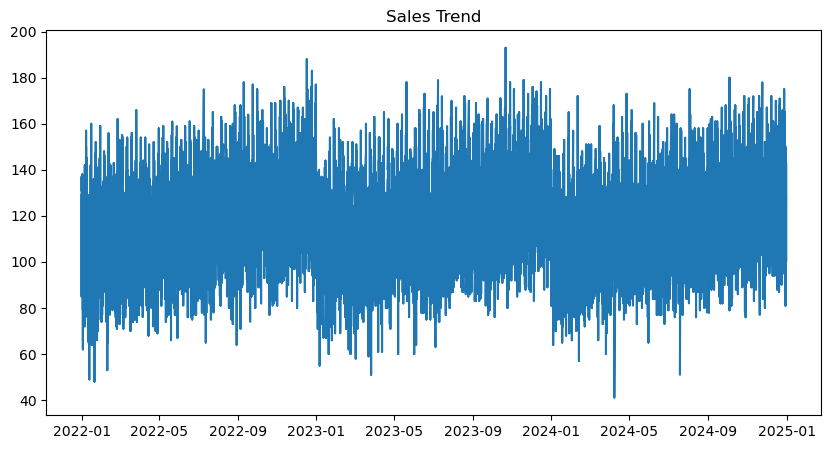

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Units_Sold'])
plt.title("Sales Trend")
plt.show()

Define Features & Target

In [22]:
X = df[['Year','Month','Day','DayOfWeek','Promotion','Holiday']]
y = df['Units_Sold']

In [23]:
X

,Year,Month,Day,DayOfWeek,Promotion,Holiday
0,2022,1,1,5,1,0
14,2022,1,1,5,0,0
13,2022,1,1,5,0,0
12,2022,1,1,5,0,0
11,2022,1,1,5,1,0
...,...,...,...,...,...,...
16426,2024,12,31,1,1,0
16425,2024,12,31,1,0,0
16438,2024,12,31,1,0,0
16431,2024,12,31,1,0,0


In [24]:
y

0        129
14       121
13       136
12       112
11       127
        ... 
16426    117
16425    100
16438    123
16431    111
16439    127
Name: Units_Sold, Length: 16440, dtype: int64

Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train, X_test, y_train, y_test

Train Model

In [26]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [27]:
y_pred = model.predict(X_test)

In [28]:
y_pred

array([124.43536925, 124.43536925, 127.60243759, ..., 122.65229598,
       122.65229598, 122.65229598], shape=(3288,))

Evaluation

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 12.469500449005798
MSE: 244.37702196001254
RMSE: 15.632562872415148


In [30]:
pickle.dump(model,open("sales.pkl", "wb"))